In [5]:
import xarray as xr
import numpy as np
from pathlib import Path

# ============================================================
# 1. PENGATURAN
# ============================================================

INPUT_DIR = Path("../olr_daily_1979_2025")
OUTPUT_DIR = Path("olr_global_1p25_lat30_ncl_ready")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FILE_PATTERN = "OLR-Daily_v02r00_s*.nc"
VAR_NAME = "olr"

TARGET_LAT = np.arange(-29.375, 30.0, 1.25).astype("float32")
TARGET_LON = np.arange(0.625, 360.0, 1.25).astype("float32")


# ============================================================
# 2. FUNGSI BANTU
# ============================================================

def standardize_coords(ds):
    rename_dict = {}

    if "latitude" in ds.coords:
        rename_dict["latitude"] = "lat"
    if "longitude" in ds.coords:
        rename_dict["longitude"] = "lon"

    if rename_dict:
        ds = ds.rename(rename_dict)

    if float(ds.lon.min()) < 0:
        ds = ds.assign_coords(lon=(ds.lon % 360))
        ds = ds.sortby("lon")

    if float(ds.lat[0]) > float(ds.lat[-1]):
        ds = ds.sortby("lat")

    return ds


def get_safe_time_encoding(ds):
    time_enc = {
        "dtype": "float64"
    }

    if "units" in ds["time"].encoding:
        time_enc["units"] = ds["time"].encoding["units"]
    elif "units" in ds["time"].attrs:
        time_enc["units"] = ds["time"].attrs["units"]
    else:
        time_enc["units"] = "days since 1800-01-01 00:00:00"

    if "calendar" in ds["time"].encoding:
        time_enc["calendar"] = ds["time"].encoding["calendar"]
    elif "calendar" in ds["time"].attrs:
        time_enc["calendar"] = ds["time"].attrs["calendar"]
    else:
        time_enc["calendar"] = "standard"

    return time_enc


def make_encoding(ds_in, var_name):
    return {
        "time": get_safe_time_encoding(ds_in),
        var_name: {
            "dtype": "float32",
            "_FillValue": -9999.0,
            "zlib": True,
            "complevel": 4,
        }
    }


# ============================================================
# 3. PROSES PER FILE
# ============================================================

files = sorted(INPUT_DIR.glob(FILE_PATTERN))

print("Jumlah file ditemukan:", len(files))

if len(files) == 0:
    raise FileNotFoundError(f"Tidak ada file ditemukan di {INPUT_DIR}")

for f in files:
    print("\nMemproses:", f.name)

    ds0 = xr.open_dataset(f, decode_times=True)
    ds = standardize_coords(ds0)

    if VAR_NAME not in ds:
        raise KeyError(f"Variabel {VAR_NAME} tidak ditemukan di {f.name}")

    da = ds[VAR_NAME]

    # subset latitude tropis
    da_sub = da.sel(lat=slice(-30, 30))

    # interpolasi ke grid 1.25 derajat
    da_125 = da_sub.interp(
        lat=TARGET_LAT,
        lon=TARGET_LON,
        method="linear"
    )

    # buat dataset output
    out = xr.Dataset(
        data_vars={
            VAR_NAME: (
                ("time", "lat", "lon"),
                da_125.values.astype("float32")
            )
        },
        coords={
            "time": ds0["time"],
            "lat": TARGET_LAT,
            "lon": TARGET_LON,
        },
        attrs=ds0.attrs.copy()
    )

    # salin atribut utama
    out[VAR_NAME].attrs = da.attrs.copy()
    out["time"].attrs = ds0["time"].attrs.copy()

    out["lat"].attrs = ds["lat"].attrs.copy()
    out["lon"].attrs = ds["lon"].attrs.copy()

    # rapikan atribut koordinat
    out["lat"].attrs["units"] = "degrees_north"
    out["lon"].attrs["units"] = "degrees_east"

    out["lat"].attrs["actual_range"] = np.array(
        [TARGET_LAT.min(), TARGET_LAT.max()],
        dtype="float32"
    )
    out["lon"].attrs["actual_range"] = np.array(
        [TARGET_LON.min(), TARGET_LON.max()],
        dtype="float32"
    )

    out[VAR_NAME].attrs["description"] = (
        "NOAA daily OLR regridded to 1.25 degree, "
        "global longitude 0-360, latitude subset -30 to 30. "
        "Time coordinate and main metadata preserved for NCL WK99."
    )

    # nama file output
    out_file = OUTPUT_DIR / f"{f.stem}_1p25_lat30_ncl_ready.nc"

    encoding = make_encoding(ds0, VAR_NAME)

    out.to_netcdf(
        out_file,
        encoding=encoding,
        engine="netcdf4"
    )

    print("Selesai:", out_file)
    print("Dimensi:", dict(out.sizes))
    print("Time awal :", str(out.time.values[0]))
    print("Time akhir:", str(out.time.values[-1]))
    print("Lat:", float(out.lat.min()), "sampai", float(out.lat.max()))
    print("Lon:", float(out.lon.min()), "sampai", float(out.lon.max()))

    ds0.close()
    ds.close()
    out.close()

# ============================================================
# 4. GABUNGKAN SEMUA FILE MENJADI SATU FILE
# ============================================================

COMBINED_FILE = OUTPUT_DIR / "olr_daily_1979_2025_global_1p25_lat30_ncl_ready.nc"

print("\nMenggabungkan semua file output...")

out_files = sorted(OUTPUT_DIR.glob("*_1p25_lat30_ncl_ready.nc"))

ds_all = xr.open_mfdataset(
    out_files,
    combine="by_coords",
    decode_times=True,
    parallel=False
)

ds_all = ds_all.sortby("time")

encoding_all = {
    "time": {
        "dtype": "float64",
        "units": ds_all["time"].encoding.get(
            "units",
            "days since 1800-01-01 00:00:00"
        ),
        "calendar": ds_all["time"].encoding.get(
            "calendar",
            "standard"
        ),
    },
    VAR_NAME: {
        "dtype": "float32",
        "_FillValue": -9999.0,
        "zlib": True,
        "complevel": 4,
    }
}

ds_all.to_netcdf(
    COMBINED_FILE,
    encoding=encoding_all,
    engine="netcdf4"
)

print("File gabungan selesai:")
print(COMBINED_FILE)
print(ds_all)

ds_all.close()

Jumlah file ditemukan: 47

Memproses: OLR-Daily_v02r00_s19790101_e19791231.nc
Selesai: olr_global_1p25_lat30_ncl_ready/OLR-Daily_v02r00_s19790101_e19791231_1p25_lat30_ncl_ready.nc
Dimensi: {'time': 365, 'lat': 48, 'lon': 288}
Time awal : 1979-01-01T12:00:00.000000000
Time akhir: 1979-12-31T12:00:00.000000000
Lat: -29.375 sampai 29.375
Lon: 0.625 sampai 359.375

Memproses: OLR-Daily_v02r00_s19800101_e19801231.nc
Selesai: olr_global_1p25_lat30_ncl_ready/OLR-Daily_v02r00_s19800101_e19801231_1p25_lat30_ncl_ready.nc
Dimensi: {'time': 366, 'lat': 48, 'lon': 288}
Time awal : 1980-01-01T12:00:00.000000000
Time akhir: 1980-12-31T12:00:00.000000000
Lat: -29.375 sampai 29.375
Lon: 0.625 sampai 359.375

Memproses: OLR-Daily_v02r00_s19810101_e19811231.nc
Selesai: olr_global_1p25_lat30_ncl_ready/OLR-Daily_v02r00_s19810101_e19811231_1p25_lat30_ncl_ready.nc
Dimensi: {'time': 365, 'lat': 48, 'lon': 288}
Time awal : 1981-01-01T12:00:00.000000000
Time akhir: 1981-12-31T12:00:00.000000000
Lat: -29.375 sam

In [6]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("olr_global_1p25_lat30_ncl_ready/olr_daily_1979_2025_global_1p25_lat30_ncl_ready.nc")
da = ds["olr"]

print("NaN:", np.isnan(da).sum().item())
print("Fill -9999:", (da == -9999).sum().item())
print("Min:", da.min().item())
print("Max:", da.max().item())

# cek grid yang punya missing sepanjang waktu
miss_grid = np.isnan(da).any("time")
print("Jumlah grid ada NaN:", miss_grid.sum().item())

NaN: 359424
Fill -9999: 0
Min: 73.03610229492188
Max: 379.19390869140625
Jumlah grid ada NaN: 13824


In [7]:
import xarray as xr
import numpy as np

INPUT_FILE = "olr_global_1p25_lat30_ncl_ready/olr_daily_1979_2025_global_1p25_lat30_ncl_ready.nc"
OUTPUT_FILE = "olr_global_1p25_lat30_ncl_ready/olr_daily_1979_2025_global_1p25_lat30_ncl_ready_nonan.nc"

ds = xr.open_dataset(INPUT_FILE)
da = ds["olr"]

print("Sebelum")
print("NaN:", np.isnan(da).sum().item())
print("Grid ada NaN:", np.isnan(da).any("time").sum().item())

# isi NaN sepanjang waktu
da_fill = da.interpolate_na(
    dim="time",
    method="linear",
    fill_value="extrapolate"
)

print("Sesudah")
print("NaN:", np.isnan(da_fill).sum().item())
print("Grid ada NaN:", np.isnan(da_fill).any("time").sum().item())

ds_out = ds.copy()
ds_out["olr"] = da_fill.astype("float32")

encoding = {
    "time": {
        "dtype": "float64",
        "units": ds["time"].encoding.get("units", "days since 1970-01-01 00:00:00"),
        "calendar": ds["time"].encoding.get("calendar", "standard"),
    },
    "olr": {
        "dtype": "float32",
        "_FillValue": -9999.0,
        "zlib": True,
        "complevel": 4,
    }
}

ds_out.to_netcdf(OUTPUT_FILE, encoding=encoding, engine="netcdf4")

print("File selesai:", OUTPUT_FILE)

Sebelum
NaN: 359424
Grid ada NaN: 13824
Sesudah
NaN: 0
Grid ada NaN: 0
File selesai: olr_global_1p25_lat30_ncl_ready/olr_daily_1979_2025_global_1p25_lat30_ncl_ready_nonan.nc


In [8]:
ds = xr.open_dataset("olr_global_1p25_lat30_ncl_ready/olr_daily_1979_2025_global_1p25_lat30_ncl_ready_nonan.nc")
da = ds["olr"]

print("NaN:", np.isnan(da).sum().item())
print("Fill -9999:", (da == -9999).sum().item())
print("Min:", da.min().item())
print("Max:", da.max().item())
print("Grid ada NaN:", np.isnan(da).any("time").sum().item())

NaN: 0
Fill -9999: 0
Min: 73.03610229492188
Max: 379.19390869140625
Grid ada NaN: 0


<xarray.Dataset> Size: 949MB
Dimensions:        (time: 17167, lat: 48, lon: 288)
Coordinates:
  * time           (time) datetime64[ns] 137kB 1979-01-01T12:00:00 ... 2025-1...
  * lat            (lat) float32 192B -29.38 -28.12 -26.88 ... 26.88 28.12 29.38
  * lon            (lon) float32 1kB 0.625 1.875 3.125 ... 356.9 358.1 359.4
Data variables:
    olrrm3harmean  (time, lat, lon) float32 949MB ...

=== CEK DASAR ===
NaN: 0
Grid ada NaN: 0
Mean: 1.8540632140684465e-07
Std: 26.9378662109375
Min: -200.42721557617188
Max: 118.19740295410156

=== DAILY CLIMATOLOGY ===
Min: -0.8940701484680176
Max: 0.7112552523612976
Std: 0.28001007437705994


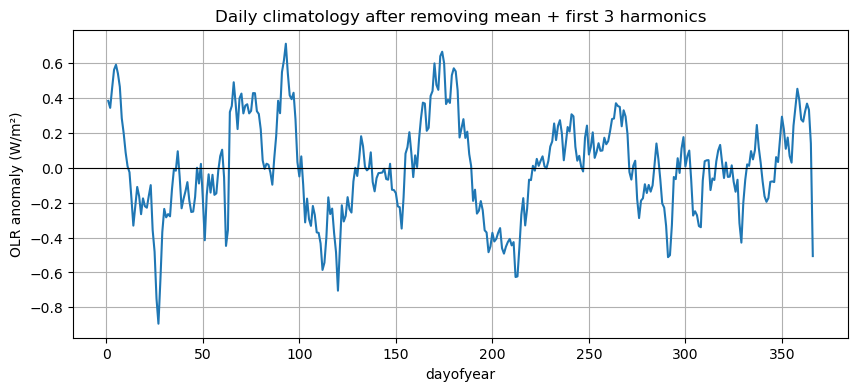


=== POWER SPECTRUM ===
365 hari power: 1.5858733e-06
182.5 hari power: 6.0523536e-07
121.7 hari power: 7.887143e-07


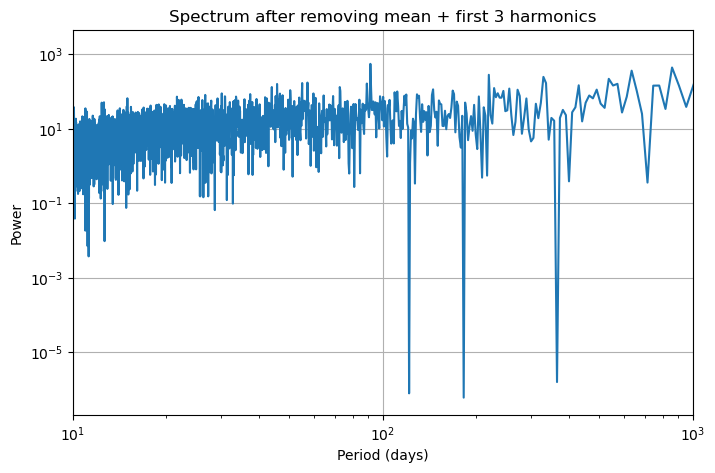

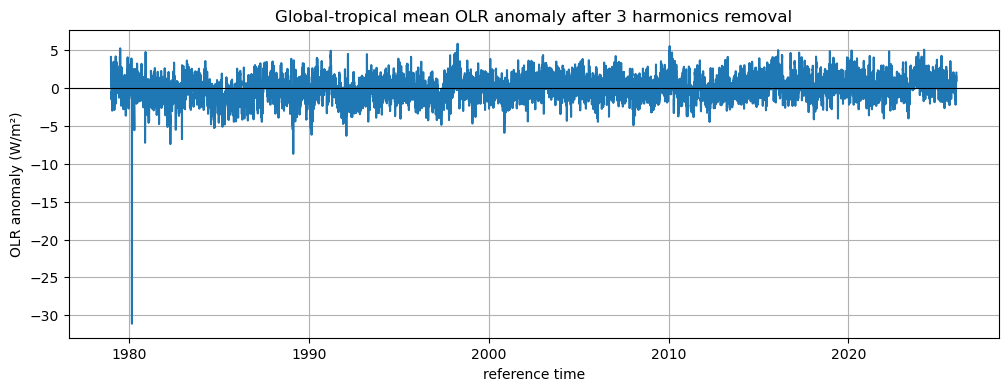

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

# ============================================================
# FILE
# ============================================================

file_rm3 = "3harmonik_new/olrrm3harmean.nc"
varname = "olrrm3harmean"

ds = xr.open_dataset(file_rm3)
da = ds[varname]

print(ds)

# ============================================================
# 1. CEK DASAR
# ============================================================

print("\n=== CEK DASAR ===")
print("NaN:", np.isnan(da).sum().item())
print("Grid ada NaN:", np.isnan(da).any("time").sum().item())
print("Mean:", da.mean().item())
print("Std:", da.std().item())
print("Min:", da.min().item())
print("Max:", da.max().item())

# ============================================================
# 2. CEK DAILY CLIMATOLOGY
# ============================================================

ts = da.mean(["lat", "lon"])
clim = ts.groupby("time.dayofyear").mean()

print("\n=== DAILY CLIMATOLOGY ===")
print("Min:", clim.min().item())
print("Max:", clim.max().item())
print("Std:", clim.std().item())

plt.figure(figsize=(10,4))
clim.plot()
plt.axhline(0, color="k", linewidth=0.8)
plt.grid(True)
plt.title("Daily climatology after removing mean + first 3 harmonics")
plt.ylabel("OLR anomaly (W/m²)")
plt.show()

# ============================================================
# 3. CEK POWER SPECTRUM
# ============================================================

f, P = periodogram(ts.values, fs=1.0)
period = 1 / f[1:]
power = P[1:]

print("\n=== POWER SPECTRUM ===")
for target in [365, 182.5, 121.7]:
    idx = np.argmin(abs(period - target))
    print(f"{target} hari power:", power[idx])

plt.figure(figsize=(8,5))
plt.loglog(period, power)
plt.xlim(10, 1000)
plt.grid(True)
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Spectrum after removing mean + first 3 harmonics")
plt.show()

# ============================================================
# 4. CEK TIME SERIES GLOBAL MEAN
# ============================================================

plt.figure(figsize=(12,4))
ts.plot()
plt.axhline(0, color="k", linewidth=0.8)
plt.grid(True)
plt.title("Global-tropical mean OLR anomaly after 3 harmonics removal")
plt.ylabel("OLR anomaly (W/m²)")
plt.show()


=== POWER COMPARISON ===
Period      Original        RM3-Harmonic Removed        Reduction (%)
  365.0    2.587999e+04            1.585873e-06      100.0000
  182.5    2.293871e+03            6.052354e-07      100.0000
  121.7    1.441575e+03            7.887143e-07      100.0000


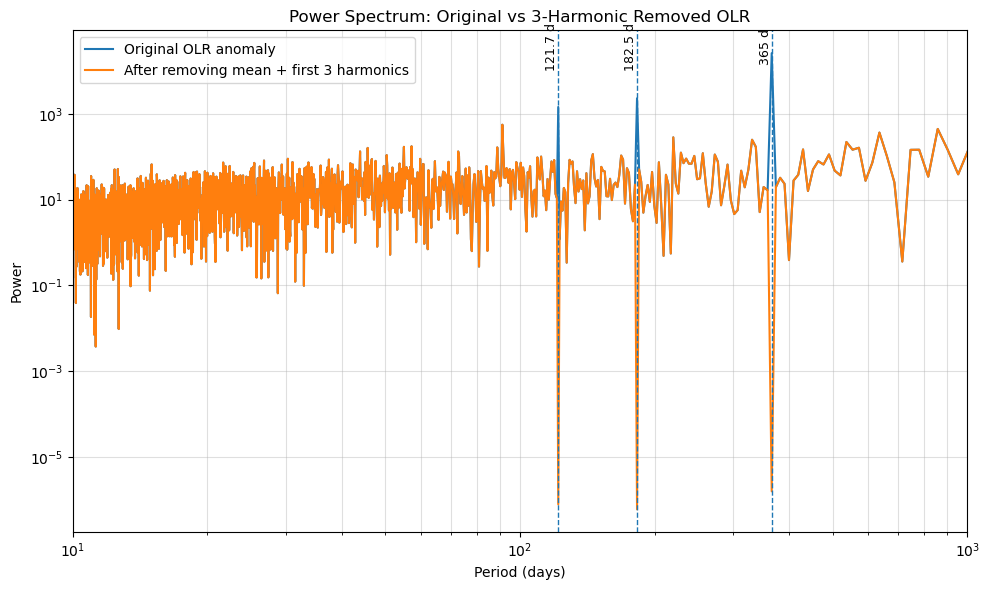

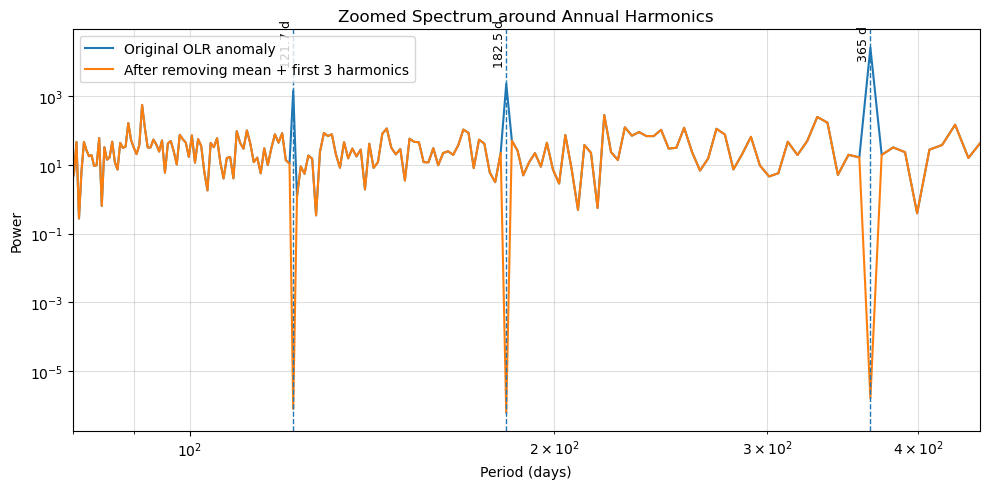

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

# ============================================================
# FILE INPUT
# ============================================================

file_ori = "olr_global_1p25_lat30_ncl_ready/olr_daily_1979_2025_global_1p25_lat30_ncl_ready_nonan.nc"
file_rm3 = "3harmonik_new/olrrm3harmean.nc"

var_ori = "olr"
var_rm3 = "olrrm3harmean"

# ============================================================
# BACA DATA
# ============================================================

ds_ori = xr.open_dataset(file_ori)
ds_rm3 = xr.open_dataset(file_rm3)

ori = ds_ori[var_ori]
rm3 = ds_rm3[var_rm3]

# samakan time jika perlu
ori = ori.sel(time=rm3.time)

# ============================================================
# GLOBAL-TROPICAL MEAN TIME SERIES
# ============================================================

ori_ts = ori.mean(["lat", "lon"])
rm3_ts = rm3.mean(["lat", "lon"])

# original dibuat anomaly dulu agar DC/mean tidak mendominasi
ori_ts_anom = ori_ts - ori_ts.mean()

# ============================================================
# POWER SPECTRUM
# ============================================================

f_ori, P_ori = periodogram(ori_ts_anom.values, fs=1.0)
f_rm3, P_rm3 = periodogram(rm3_ts.values, fs=1.0)

period_ori = 1 / f_ori[1:]
power_ori = P_ori[1:]

period_rm3 = 1 / f_rm3[1:]
power_rm3 = P_rm3[1:]

# ============================================================
# CETAK NILAI POWER PADA HARMONIK UTAMA
# ============================================================

print("\n=== POWER COMPARISON ===")
print("Period      Original        RM3-Harmonic Removed        Reduction (%)")

for target in [365, 182.5, 121.7]:
    idx_ori = np.argmin(abs(period_ori - target))
    idx_rm3 = np.argmin(abs(period_rm3 - target))

    po = power_ori[idx_ori]
    pr = power_rm3[idx_rm3]

    reduction = 100 * (1 - pr / po)

    print(f"{target:7.1f}  {po:14.6e}  {pr:22.6e}  {reduction:12.4f}")

# ============================================================
# PLOT SPEKTRUM
# ============================================================

plt.figure(figsize=(10,6))

plt.loglog(period_ori, power_ori, label="Original OLR anomaly")
plt.loglog(period_rm3, power_rm3, label="After removing mean + first 3 harmonics")

# garis referensi harmonik
for p, lab in zip([365, 182.5, 121.7], ["365 d", "182.5 d", "121.7 d"]):
    plt.axvline(p, linestyle="--", linewidth=1)
    plt.text(p, plt.ylim()[1]*0.4, lab, rotation=90,
             va="center", ha="right", fontsize=9)

plt.xlim(10, 1000)
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Power Spectrum: Original vs 3-Harmonic Removed OLR")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PLOT ZOOM 80–450 HARI
# ============================================================

plt.figure(figsize=(10,5))

plt.loglog(period_ori, power_ori, label="Original OLR anomaly")
plt.loglog(period_rm3, power_rm3, label="After removing mean + first 3 harmonics")

for p, lab in zip([365, 182.5, 121.7], ["365 d", "182.5 d", "121.7 d"]):
    plt.axvline(p, linestyle="--", linewidth=1)
    plt.text(p, plt.ylim()[1]*0.4, lab, rotation=90,
             va="center", ha="right", fontsize=9)

plt.xlim(80, 450)
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Zoomed Spectrum around Annual Harmonics")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import xarray as xr
import numpy as np

for wave in ["er","kelvin","mjo","mrg"]:

    ds = xr.open_dataset(f"wk99_output_wave/wk_{wave}_olr.nc")

    var = list(ds.data_vars)[0]

    x = ds[var]

    print(wave.upper())

    print("NaN :", np.isnan(x).sum().item())

    print("Mean :", float(x.mean()))

    print("Std :", float(x.std()))

    print("Min :", float(x.min()))

    print("Max :", float(x.max()))

    print()

ER
NaN : 0
Mean : -7.457186951276285e-11
Std : 7.545153617858887
Min : -55.160404205322266
Max : 57.22208023071289

KELVIN
NaN : 0
Mean : 7.515054550877309e-11
Std : 8.809706687927246
Min : -76.2313232421875
Max : 62.27471160888672

MJO
NaN : 0
Mean : 2.854794959455953e-12
Std : 6.933592319488525
Min : -56.332881927490234
Max : 64.00763702392578

MRG
NaN : 0
Mean : -4.436505676719271e-11
Std : 4.636347770690918
Min : -42.64350509643555
Max : 43.75335693359375



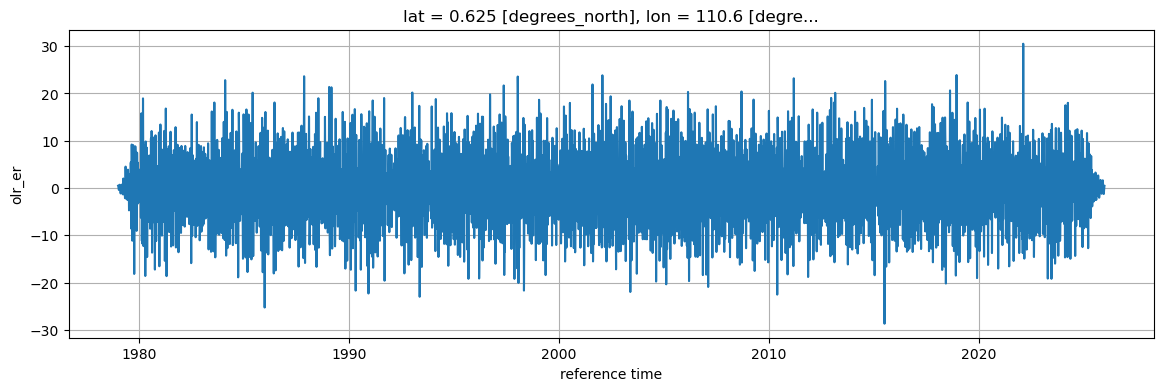

In [2]:
import matplotlib.pyplot as plt

ds=xr.open_dataset("wk99_output_wave/wk_er_olr.nc")

var=list(ds.data_vars)[0]

ts=ds[var].sel(lat=0,lon=110,method="nearest")

plt.figure(figsize=(14,4))

ts.plot()

plt.grid()

plt.show()

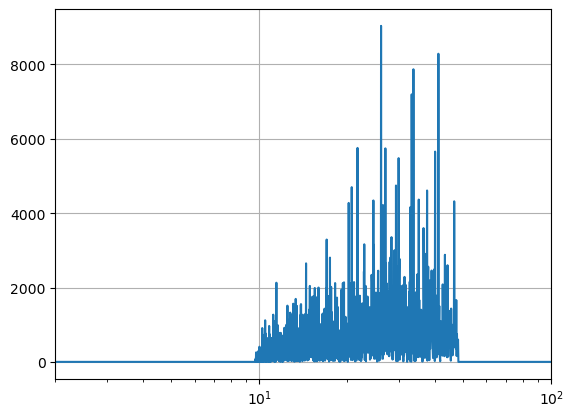

In [3]:
from scipy.signal import periodogram

ts=ds[var].sel(lat=0,lon=110,method="nearest").values

f,P=periodogram(ts)

period=1/f[1:]

plt.semilogx(period,P[1:])

plt.xlim(2,100)

plt.grid()

plt.show()

In [4]:
orig=xr.open_dataset("3harmonik_new/olrrm3harmean.nc")

er=xr.open_dataset("wk99_output_wave/wk_er_olr.nc")

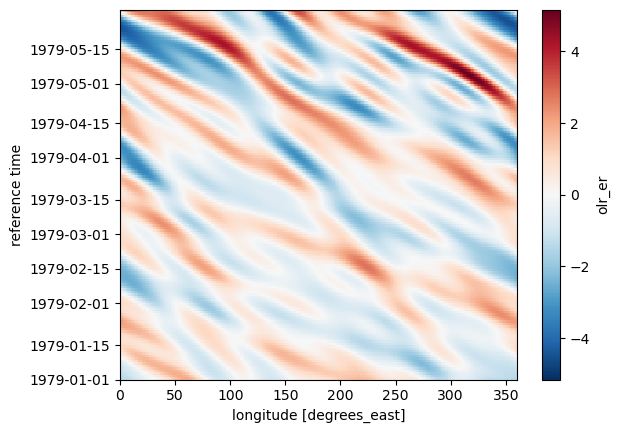

In [5]:
hov=ds[var].sel(lat=slice(-5,5)).mean("lat")

hov.isel(time=slice(0,150)).plot()

plt.show()

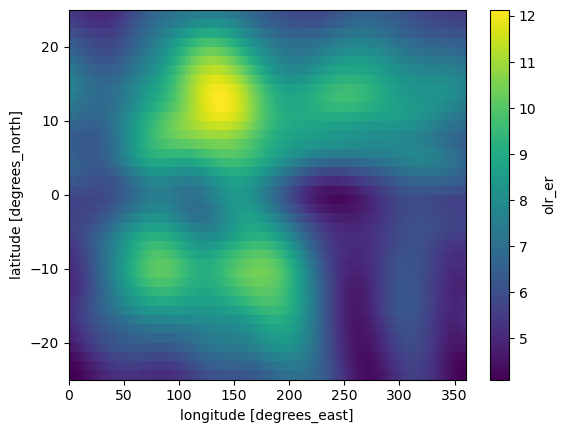

In [6]:
rms=np.sqrt((ds[var]**2).mean("time"))

rms.plot()

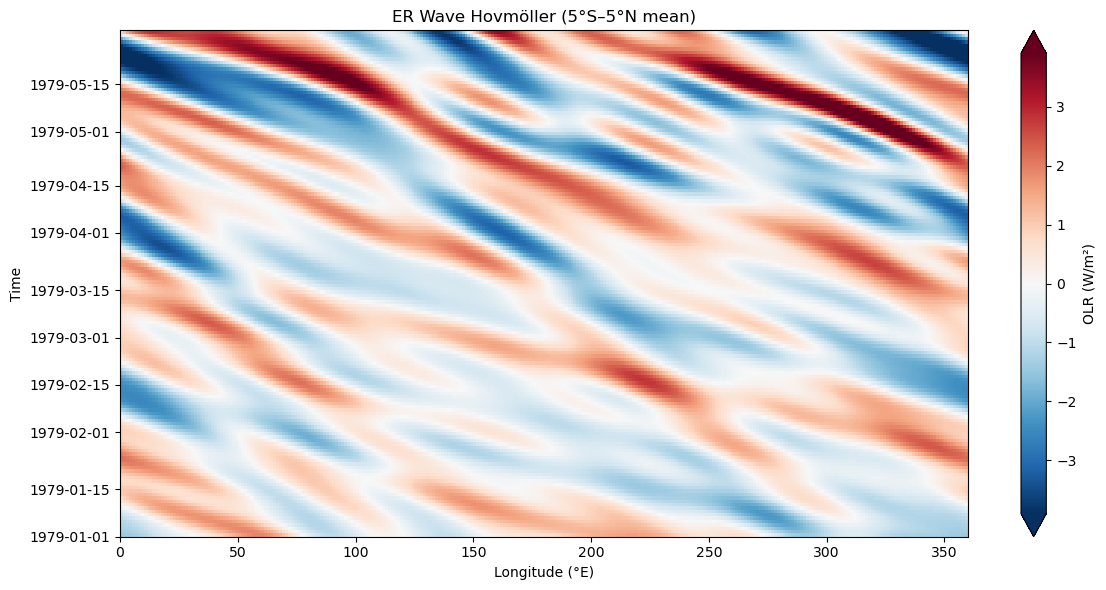

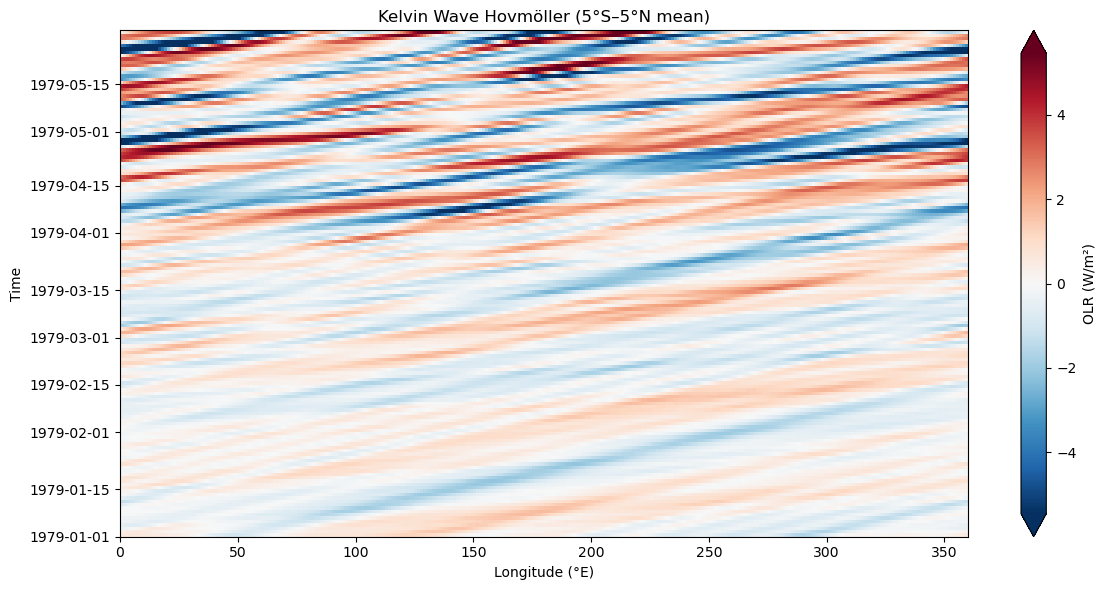

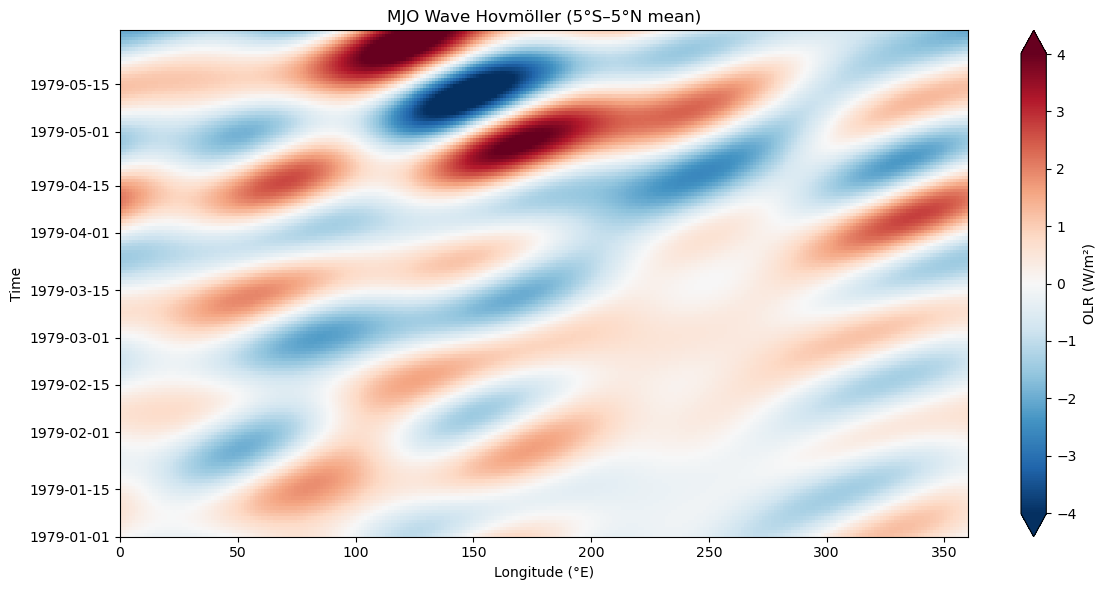

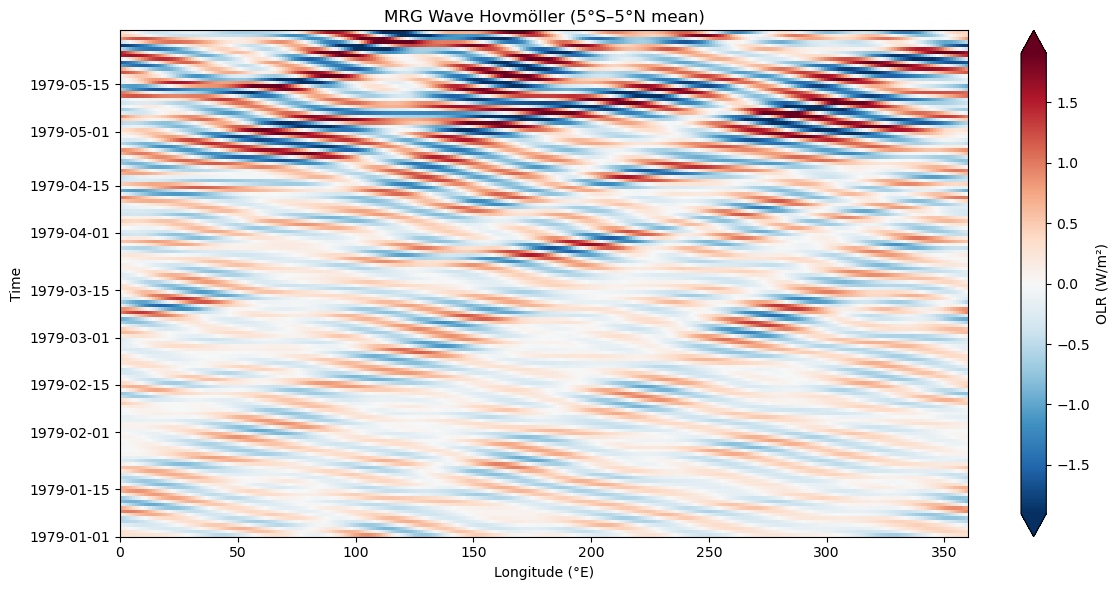

In [7]:
import xarray as xr
import matplotlib.pyplot as plt

# ============================================================
# Daftar file
# ============================================================

waves = {
    "ER"     : "wk99_output_wave/wk_er_olr.nc",
    "Kelvin" : "wk99_output_wave/wk_kelvin_olr.nc",
    "MJO"    : "wk99_output_wave/wk_mjo_olr.nc",
    "MRG"    : "wk99_output_wave/wk_mrg_olr.nc"
}

# ============================================================
# Plot Hovmoller
# ============================================================

for wave,file in waves.items():

    ds = xr.open_dataset(file)

    var = list(ds.data_vars)[0]

    # rata-rata 5S-5N
    hov = ds[var].sel(lat=slice(-5,5)).mean("lat")

    # ambil 150 hari pertama agar pola mudah dilihat
    hov = hov.isel(time=slice(0,150))

    plt.figure(figsize=(12,6))

    vmax = float(abs(hov).quantile(0.99))

    hov.plot(
        x="lon",
        y="time",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        cbar_kwargs={"label":"OLR (W/m²)"}
    )

    plt.title(f"{wave} Wave Hovmöller (5°S–5°N mean)")
    plt.xlabel("Longitude (°E)")
    plt.ylabel("Time")

    plt.tight_layout()

    plt.show()